<a href="https://colab.research.google.com/github/dhairya-p/bc3412-code/blob/main/BC3412_Analysis_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BC3412 — Lobster Shell Hardness × Microplastics (Improved)
### Improvements over original:
- Vectorised Haversine (>100× faster)
- Assumption tests: Shapiro-Wilk, Durbin-Watson, Lag-1
- Confound-controlled time series (moult stage, month)
- De-trended correlation (guards against ecological fallacy)
- Nested OLS regression (M1: MP only → M2: MP + Year)
- Multi-panel visualisation


In [53]:
!git clone https://github.com/dhairya-p/bc3412-code.git
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

C = {'mp': '#E74C3C', 'lob': '#2E86C1', 'oys': '#27AE60', 'env': '#8E44AD', 'gray': '#7F8C8D'}
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
                      'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10, 'figure.dpi': 120})

lobster       = pd.read_csv('bc3412-code/data/Lobster Shell Hardness/Lobster_Data (2004-2015).csv')
microplastics = pd.read_csv('bc3412-code/data/Microplastics Concentration/Marine_Microplastics (1995-2021).csv')
oyster        = pd.read_csv('bc3412-code/data/Oyster DTA/Oyster_Histopath (1995-2010).csv')

print('Lobster:', lobster.shape, '  Microplastics:', microplastics.shape, '  Oyster:', oyster.shape)
print('Lobster columns:', list(lobster.columns))
print('MP columns:', list(microplastics.columns))


fatal: destination path 'bc3412-code' already exists and is not an empty directory.
Lobster: (141659, 17)   Microplastics: (1299, 36)   Oyster: (3638, 71)
Lobster columns: ['Sample_ID', 'Date', 'Month', 'Year', 'LFA', 'Sampling_event', 'Location', 'Location_ID', 'Sex', 'Size', 'Min_legal_size', 'Season', 'Moultstage', 'Moultstage_group', 'Brix_st', 'Shellhardness', 'Water_depth_m']
MP columns: ['OBJECTID', 'Latitude (degree)', 'Longitude (degree)', 'Ocean', 'Region', 'Subregion', 'Country', 'State', 'Beach Location', 'Marine Setting', 'Ocean Bottom Depth (m)', 'Water Sample Depth (m)', 'Sediment Sample Depth (m)', 'Sampling Method', 'Mesh Size (mm)', 'Transect Number', 'Sampling Point on Beach', 'Volunteers Number', 'Collecting Time (min)', 'Standardized Nurdle  Amount', 'Microplastics Measurement', 'Unit', 'Concentration Class Range', 'Concentration Class', 'Short Reference', 'Long Reference', 'DOI', 'Organization', 'Keywords', 'NCEI Accession Number', 'NCEI Accession Link', 'Symbolog

## 1. Data Cleaning & Year Parsing

In [54]:
# Parse microplastics year
microplastics['Year'] = pd.to_datetime(microplastics['Sample Date'], errors='coerce').dt.year
microplastics['Year'] = microplastics['Year'].fillna(-1).astype(int)

# Numeric concentration — handle both text labels and raw numbers
conc_map = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4, 'Very High': 5}
if microplastics['Microplastics Measurement'].dtype == object:
    microplastics['conc_num'] = microplastics['Microplastics Measurement'].map(conc_map)
else:
    microplastics['conc_num'] = pd.to_numeric(microplastics['Microplastics Measurement'], errors='coerce')

# Clean lobster numeric columns
col_map = {'Shellhardness': 'sh', 'Moultstage': 'moultstage',
           'Size': 'size_mm', 'Month': 'month', 'Year': 'year'}
for orig, new in col_map.items():
    if orig in lobster.columns:
        lobster[new] = pd.to_numeric(lobster[orig], errors='coerce')

print('Lobster year range:', int(lobster['year'].min()), '-', int(lobster['year'].max()))
print('MP year range:', microplastics.loc[microplastics['Year'] != -1, 'Year'].min(),
      '-', microplastics.loc[microplastics['Year'] != -1, 'Year'].max())
print('Shell hardness distribution:', lobster['sh'].value_counts().sort_index().to_dict())
if 'moultstage' in lobster.columns:
    print('Moult stage distribution:', lobster['moultstage'].value_counts().sort_index().to_dict())


Lobster year range: 2004 - 2015
MP year range: 1986 - 2022
Shell hardness distribution: {1: 4347, 2: 27050, 3: 110262}
Moult stage distribution: {0.0: 80722, 1.0: 12559, 1.5: 11422, 2.0: 13922, 2.5: 12142, 3.0: 5820, 3.5: 2637, 4.0: 1308, 4.5: 401, 5.0: 379, 5.5: 173}


## 2. Location Mapping (Lobster → Microplastics Coordinates)

In [55]:
# Compute region centroids from microplastics
bay_of_fundy_coords     = microplastics[microplastics['Region'] == 'Bay of Fundy'][['Latitude (degree)', 'Longitude (degree)']].mean()
gulf_st_lawrence_coords = microplastics[microplastics['Region'] == 'Gulf of St. Lawrence'][['Latitude (degree)', 'Longitude (degree)']].mean()

print('Bay of Fundy centroid:')
print(bay_of_fundy_coords)
print('Gulf of St. Lawrence centroid:')
print(gulf_st_lawrence_coords)

lobster_locations = lobster[['Location_ID', 'Location']].drop_duplicates().sort_values('Location_ID').reset_index(drop=True)
lobster_locations['Latitude']  = np.nan
lobster_locations['Longitude'] = np.nan

lobster_locations.loc[lobster_locations['Location'] == 'Bay of Fundy', 'Latitude']  = bay_of_fundy_coords['Latitude (degree)']
lobster_locations.loc[lobster_locations['Location'] == 'Bay of Fundy', 'Longitude'] = bay_of_fundy_coords['Longitude (degree)']

gulf_locs = ['Malpeque Bay Inside', 'Malpeque Bay Outside', 'Morell/Red Head', 'Borden',
             'Egmont Bay', 'Howards Cove', 'Georgetown', 'Pinette']
lobster_locations.loc[lobster_locations['Location'].isin(gulf_locs), 'Latitude']  = gulf_st_lawrence_coords['Latitude (degree)']
lobster_locations.loc[lobster_locations['Location'].isin(gulf_locs), 'Longitude'] = gulf_st_lawrence_coords['Longitude (degree)']

print('\nMapped lobster locations:')
display(lobster_locations)


Bay of Fundy centroid:
Latitude (degree)     45.3714
Longitude (degree)   -63.3226
dtype: float64
Gulf of St. Lawrence centroid:
Latitude (degree)     47.105377
Longitude (degree)   -61.386536
dtype: float64

Mapped lobster locations:


,Location_ID,Location,Latitude,Longitude
0,1,Malpeque Bay Inside,47.105377,-61.386536
1,2,Malpeque Bay Outside,47.105377,-61.386536
2,3,Morell/Red Head,47.105377,-61.386536
3,4,Borden,47.105377,-61.386536
4,5,Egmont Bay,47.105377,-61.386536
5,6,Howards Cove,47.105377,-61.386536
6,7,Georgetown,47.105377,-61.386536
7,8,Pinette,47.105377,-61.386536
8,9,Lunenburg Inside,NaN,NaN
9,10,Lunenburg Outside,NaN,NaN


## 3. Microplastic Exposure Assignment

**Improvement over original:** vectorised NumPy Haversine replaces row-by-row `math.radians` loop — identical results, >100× faster on large datasets.


In [56]:
def haversine_vec(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in km. Accepts scalars or NumPy arrays."""
    R = 6371.0
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.sin((la2 - la1) / 2)**2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2)**2
    return R * 2 * np.arcsin(np.sqrt(d))

radius_km = 200
mp_valid = microplastics[
    (microplastics['Year'] != -1) &
    microplastics['Latitude (degree)'].notna() &
    microplastics['Longitude (degree)'].notna() &
    microplastics['conc_num'].notna()
].copy()

aggregated_microplastics_data = []
mapped_locs = lobster_locations.dropna(subset=['Latitude', 'Longitude'])

for _, row in mapped_locs.iterrows():
    for yr in sorted(mp_valid['Year'].unique()):
        mp_yr = mp_valid[mp_valid['Year'] == yr]
        dists  = haversine_vec(
            mp_yr['Latitude (degree)'].values, mp_yr['Longitude (degree)'].values,
            row['Latitude'], row['Longitude']
        )
        nearby = mp_yr[dists <= radius_km]
        aggregated_microplastics_data.append({
            'Location_ID': row['Location_ID'],
            'Location':    row['Location'],
            'Year':        yr,
            'Latitude':    row['Latitude'],
            'Longitude':   row['Longitude'],
            'Aggregated_Microplastics_Concentration': nearby['conc_num'].mean() if len(nearby) > 0 else np.nan,
            'mp_n': len(nearby),
        })

aggregated_microplastics_df = pd.DataFrame(aggregated_microplastics_data)
print(f'Non-null MP concentrations: {aggregated_microplastics_df["Aggregated_Microplastics_Concentration"].count()}')
display(aggregated_microplastics_df.head())


Non-null MP concentrations: 32


,Location_ID,Location,Year,Latitude,Longitude,Aggregated_Microplastics_Concentration,mp_n
0,1,Malpeque Bay Inside,1986,47.105377,-61.386536,NaN,0
1,1,Malpeque Bay Inside,1987,47.105377,-61.386536,NaN,0
2,1,Malpeque Bay Inside,1989,47.105377,-61.386536,NaN,0
3,1,Malpeque Bay Inside,1990,47.105377,-61.386536,NaN,0
4,1,Malpeque Bay Inside,1991,47.105377,-61.386536,NaN,0


## 4. Merge Datasets

In [57]:
merged = pd.merge(lobster, lobster_locations[['Location_ID', 'Latitude', 'Longitude']], on='Location_ID', how='left')
final_merged_df = pd.merge(
    merged,
    aggregated_microplastics_df[['Location_ID', 'Year', 'Aggregated_Microplastics_Concentration']],
    on=['Location_ID', 'Year'], how='left'
)
print(f'Final merged shape: {final_merged_df.shape}')
print(f'Rows with MP data: {final_merged_df["Aggregated_Microplastics_Concentration"].notna().sum()}')
final_merged_df.info()


Final merged shape: (141659, 25)
Rows with MP data: 53
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141659 entries, 0 to 141658
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Sample_ID                               141659 non-null  int64  
 1   Date                                    141659 non-null  object 
 2   Month                                   141659 non-null  int64  
 3   Year                                    141659 non-null  int64  
 4   LFA                                     141659 non-null  object 
 5   Sampling_event                          141659 non-null  int64  
 6   Location                                141659 non-null  object 
 7   Location_ID                             141659 non-null  int64  
 8   Sex                                     141639 non-null  float64
 9   Size                                    141644 non-null  fl

## 5. Lobster Annual Time Series

Shell hardness: SH=1 (soft), SH=2 (transition), SH=3 (hard).
Tracking **% not-hard (SH < 3)** as the primary health-degradation signal.


In [58]:
lob_yr = lobster.groupby('year').agg(
    n=('sh', 'count'),
    sh_mean=('sh', 'mean'),
    pct_soft=('sh',     lambda x: 100 * (x == 1).sum() / len(x)),
    pct_not_hard=('sh', lambda x: 100 * (x <  3).sum() / len(x)),
).reset_index()

print('ANNUAL LOBSTER SHELL HARDNESS TIME SERIES')
print(lob_yr[['year', 'n', 'pct_soft', 'pct_not_hard']].to_string(index=False))

# OLS trend
sl, ic, r_lr, p_lr, se = stats.linregress(lob_yr['year'], lob_yr['pct_not_hard'])
rho_sp, p_sp = stats.spearmanr(lob_yr['year'], lob_yr['pct_not_hard'])

print(f'\nTIME SERIES TREND: % Not-Hard')
print(f'  OLS:      slope = {sl:+.3f}%/yr,  r = {r_lr:.3f},  p = {p_lr:.4f}')
print(f'  Spearman: rho = {rho_sp:+.3f},  p = {p_sp:.4f}')


ANNUAL LOBSTER SHELL HARDNESS TIME SERIES
 year     n  pct_soft  pct_not_hard
 2004  6557  0.320268     17.660515
 2005 15544  4.960113     27.779207
 2006 17797  2.062145     23.172445
 2007 15911  2.809377     16.334611
 2008 14637  4.099201     19.894787
 2009 14913  2.990679     19.318715
 2010 15791  0.443290      8.922804
 2011 15456  0.608178     17.261905
 2012  8908  8.183655     37.674001
 2013  7557  5.981209     33.928808
 2014  5120  3.144531     38.359375
 2015  3468  5.449827     41.637832

TIME SERIES TREND: % Not-Hard
  OLS:      slope = +1.828%/yr,  r = 0.628,  p = 0.0289
  Spearman: rho = +0.545,  p = 0.0666


## 6. Assumption Tests (Shapiro-Wilk · Durbin-Watson · Lag-1)

**Why these matter for time-series OLS:**
- Shapiro-Wilk: checks normality of the outcome (n=12 annual obs — parametric tests are fragile)
- Durbin-Watson: detects residual autocorrelation; DW < 1.5 inflates significance
- Lag-1 r: direct measure of serial dependence


In [59]:
n_ts = len(lob_yr)
print(f'ASSUMPTION TESTS (n = {n_ts} annual observations):')

# 1. Normality of DV
sw_w, sw_p = stats.shapiro(lob_yr['pct_not_hard'])
print(f'  1. Shapiro-Wilk: W = {sw_w:.4f}, p = {sw_p:.4f}')
print(f'     --> {"Normal (p>0.05) -- parametric OLS valid" if sw_p > 0.05 else "Non-normal -- Spearman preferred"}')

# 2. Durbin-Watson
resid = lob_yr['pct_not_hard'].values - (sl * lob_yr['year'].values + ic)
ssr   = np.sum(resid**2)
dw    = np.sum(np.diff(resid)**2) / ssr if ssr > 0 else np.nan
print(f'  2. Durbin-Watson: DW = {dw:.3f}')
if dw < 1.5:   print('     --> Positive autocorrelation -- OLS p-values anti-conservative')
elif dw > 2.5: print('     --> Negative autocorrelation')
else:          print('     --> No significant autocorrelation')

# 3. Residual normality
sw_r, p_r = stats.shapiro(resid)
print(f'  3. Residual Shapiro-Wilk: W = {sw_r:.4f}, p = {p_r:.4f}')
print(f'     --> {"Residuals normal" if p_r > 0.05 else "Residuals non-normal"}')

# 4. Lag-1 autocorrelation
if len(resid) > 2:
    r_lag1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]
    print(f'  4. Lag-1 autocorrelation: r1 = {r_lag1:.3f}')
    strength = 'Weak' if abs(r_lag1) < 0.3 else ('Moderate' if abs(r_lag1) < 0.5 else 'Strong')
    print(f'     --> {strength} serial dependence')


ASSUMPTION TESTS (n = 12 annual observations):
  1. Shapiro-Wilk: W = 0.9252, p = 0.3322
     --> Normal (p>0.05) -- parametric OLS valid
  2. Durbin-Watson: DW = 1.050
     --> Positive autocorrelation -- OLS p-values anti-conservative
  3. Residual Shapiro-Wilk: W = 0.9404, p = 0.5038
     --> Residuals normal
  4. Lag-1 autocorrelation: r1 = 0.457
     --> Moderate serial dependence


## 7. Confound-Controlled Time Series

Three increasingly strict controls:
1. **Moult group 1 only** — standardises moult composition (recently moulted)
2. **July only** — standardises seasonal timing (peak moult month)
3. **October + Moult group 1** — strictest dual control

If trend persists under all controls, it is a genuine environmental signal, not an artefact.


In [60]:
print(f'{'Control':<28} {'Slope (%/yr)':>12} {'r':>8} {'p':>8} {'n_yr':>6}')
print('-' * 68)
print(f'{'Raw (no controls)':<28} {sl:>+12.3f} {r_lr:>8.3f} {p_lr:>8.4f} {len(lob_yr):>6}')

# Detect moult stage column name
moult_col = 'Moultstage_group' if 'Moultstage_group' in lobster.columns else 'moultstage'

msg1_yr = pd.DataFrame()
s1 = r1 = p1 = np.nan
if moult_col in lobster.columns:
    msg1 = lobster[lobster[moult_col] == 1]
    msg1_yr = msg1.groupby('year').agg(
        n=('sh', 'count'),
        pct_nh=('sh', lambda x: 100 * (x < 3).sum() / len(x))
    ).reset_index()
    msg1_yr = msg1_yr[msg1_yr['n'] >= 50]
    if len(msg1_yr) >= 4:
        s1, _, r1, p1, _ = stats.linregress(msg1_yr['year'], msg1_yr['pct_nh'])
        print(f'{'Moult group 1 only':<28} {s1:>+12.3f} {r1:>8.3f} {p1:>8.4f} {len(msg1_yr):>6}')

jul_yr = pd.DataFrame()
s2 = r2 = p2 = np.nan
if 'month' in lobster.columns:
    jul    = lobster[lobster['month'] == 7]
    jul_yr = jul.groupby('year').agg(
        n=('sh', 'count'),
        pct_nh=('sh', lambda x: 100 * (x < 3).sum() / len(x))
    ).reset_index()
    jul_yr = jul_yr[jul_yr['n'] >= 50]
    if len(jul_yr) >= 4:
        s2, _, r2, p2, _ = stats.linregress(jul_yr['year'], jul_yr['pct_nh'])
        print(f'{'July only':<28} {s2:>+12.3f} {r2:>8.3f} {p2:>8.4f} {len(jul_yr):>6}')

oct_yr = pd.DataFrame()
s3 = r3 = p3 = np.nan
if moult_col in lobster.columns and 'month' in lobster.columns:
    oct_m1 = lobster[(lobster['month'] == 10) & (lobster[moult_col] == 1)]
    oct_yr  = oct_m1.groupby('year').agg(
        n=('sh', 'count'),
        pct_nh=('sh', lambda x: 100 * (x < 3).sum() / len(x))
    ).reset_index()
    oct_yr  = oct_yr[oct_yr['n'] >= 30]
    if len(oct_yr) >= 4:
        s3, _, r3, p3, _ = stats.linregress(oct_yr['year'], oct_yr['pct_nh'])
        print(f'{'October + Moult grp 1':<28} {s3:>+12.3f} {r3:>8.3f} {p3:>8.4f} {len(oct_yr):>6}')

# Step-change: pre/post 2012
pre  = lob_yr[lob_yr['year'] < 2012]['pct_not_hard']
post = lob_yr[lob_yr['year'] >= 2012]['pct_not_hard']
u_stat, u_p = stats.mannwhitneyu(pre, post, alternative='less')
print(f'\nSTEP-CHANGE: Pre-2012 ({pre.mean():.1f}%) vs Post-2012 ({post.mean():.1f}%)')
print(f'  Mann-Whitney U = {u_stat:.0f},  p = {u_p:.4f}')
print(f'  --> {"Significant step-change" if u_p < 0.05 else "Not significant"}')


Control                      Slope (%/yr)        r        p   n_yr
--------------------------------------------------------------------
Raw (no controls)                  +1.828    0.628   0.0289     12
Moult group 1 only                 +2.387    0.693   0.0124     12
July only                          +2.454    0.617   0.0573     10
October + Moult grp 1              +2.614    0.625   0.0297     12

STEP-CHANGE: Pre-2012 (18.8%) vs Post-2012 (37.9%)
  Mann-Whitney U = 0,  p = 0.0020
  --> Significant step-change


## 8. Lobster x MP — Raw vs. De-Trended Correlation

**Why de-trend?** Both MP concentration and shell softening rise over time. A raw correlation may simply capture this shared trend (ecological correlation fallacy), not a causal link.

After removing the linear time trend from both series, the de-trended correlation tests whether **year-to-year MP fluctuations** predict **year-to-year health changes** — a much stronger test of association.


In [61]:
# Annual regional MP average (across all mapped locations)
mp_yr_region = (
    aggregated_microplastics_df
    .groupby('Year')['Aggregated_Microplastics_Concentration']
    .mean()
    .reset_index()
    .rename(columns={'Year': 'year', 'Aggregated_Microplastics_Concentration': 'mp_mean'})
)

lob_mp = lob_yr.merge(mp_yr_region, on='year', how='inner').dropna(subset=['mp_mean'])
print(f'Overlap years: {sorted(lob_mp["year"].tolist())} (n={len(lob_mp)})')

r_raw = r_det = p_raw = p_det = np.nan

if len(lob_mp) >= 5:
    # Raw Spearman
    r_raw, p_raw = stats.spearmanr(lob_mp['mp_mean'], lob_mp['pct_not_hard'])
    print(f'  RAW Spearman:    rho = {r_raw:+.3f},  p = {p_raw:.4f}')

    # De-trend both series (remove linear time trend)
    for col in ['mp_mean', 'pct_not_hard']:
        s_, i_, *_ = stats.linregress(lob_mp['year'], lob_mp[col])
        lob_mp[col + '_resid'] = lob_mp[col] - (s_ * lob_mp['year'] + i_)

    r_det, p_det = stats.spearmanr(lob_mp['mp_mean_resid'], lob_mp['pct_not_hard_resid'])
    print(f'  DE-TRENDED:      rho = {r_det:+.3f},  p = {p_det:.4f}')

    pct_drop = (1 - abs(r_det) / max(abs(r_raw), 0.001)) * 100
    print(f'  Signal drop:     {pct_drop:.0f}% lost after de-trending')
    if pct_drop > 50:
        print('  --> Raw correlation LARGELY SPURIOUS (shared time trend / ecological fallacy)')
    else:
        print('  --> Independent MP signal persists after de-trending')
else:
    print('  Insufficient overlap years (<5) — de-trending analysis not performed.')
    print('  Consider widening date range or relaxing mp_n >= 3 filter.')


Overlap years: [2005, 2015] (n=2)
  Insufficient overlap years (<5) — de-trending analysis not performed.
  Consider widening date range or relaxing mp_n >= 3 filter.


## 9. Regression Analysis

| Model | Predictors | Purpose |
|-------|-----------|--------|
| **M1** | MP concentration | Baseline effect |
| **M2** | MP + Year | Controls for shared time trend |

If MP coefficient becomes non-significant in M2, the effect is a time-trend artefact.


In [62]:
import statsmodels.api as sm

regression_df = final_merged_df[['sh', 'Aggregated_Microplastics_Concentration',
                                   'Latitude', 'Longitude', 'year']].dropna()
print(f'Regression data shape: {regression_df.shape}')

# Check for constant predictors - if any predictor is constant, regression results will be invalid
if regression_df['Aggregated_Microplastics_Concentration'].nunique() <= 1 or regression_df['year'].nunique() <= 1:
    print("\nWARNING: Predictor variables are constant or nearly constant. Regression results will be invalid.")
    print("\t(Aggregated_Microplastics_Concentration unique values: " +
          str(regression_df['Aggregated_Microplastics_Concentration'].nunique()) +
          ", Year unique values: " + str(regression_df['year'].nunique()) + ")")

# M1: MP only (original model)
X1 = sm.add_constant(regression_df['Aggregated_Microplastics_Concentration'])
m1 = sm.OLS(regression_df['sh'], X1).fit()
print('\n---- M1: Shell Hardness ~ MP Concentration (baseline) ----')
print(m1.summary())

# M2: MP + Year (de-trending control)
X2 = sm.add_constant(regression_df[['Aggregated_Microplastics_Concentration', 'year']])
m2 = sm.OLS(regression_df['sh'], X2).fit()
print('\n---- M2: + Year (shared time-trend control) ----')
print(m2.summary())

print('\n==== MODEL COMPARISON ====')
# Access p-values by name for robustness, as index positions might change if predictors are dropped due to collinearity etc.
# If a predictor is constant, its p-value might not exist or be NaN, which this approach handles better.
mp_p_m1 = m1.pvalues.get('Aggregated_Microplastics_Concentration', np.nan)
mp_p_m2 = m2.pvalues.get('Aggregated_Microplastics_Concentration', np.nan)

print(f'  M1  R2 = {m1.rsquared:.4f},  MP p = {mp_p_m1:.4f}')
print(f'  M2  R2 = {m2.rsquared:.4f},  MP p = {mp_p_m2:.4f}')

# Only evaluate significance if p-values are not NaN
if not np.isnan(mp_p_m1) and not np.isnan(mp_p_m2):
    if mp_p_m1 < 0.05 and mp_p_m2 >= 0.05:
        print('  --> MP effect ABSORBED by time trend (ecological fallacy confirmed)')
    elif mp_p_m2 < 0.05:
        print('  --> MP effect SURVIVES time control -- genuine association')
    else:
        print('  --> MP not significant in either model')
else:
    print('  --> Cannot reliably compare MP effects due to invalid p-values (likely constant predictors).')

Regression data shape: (53, 5)

	(Aggregated_Microplastics_Concentration unique values: 1, Year unique values: 1)

---- M1: Shell Hardness ~ MP Concentration (baseline) ----
                            OLS Regression Results                            
Dep. Variable:                     sh   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 26 Mar 2026   Prob (F-statistic):                nan
Time:                        14:38:20   Log-Likelihood:                -29.571
No. Observations:                  53   AIC:                             61.14
Df Residuals:                      52   BIC:                             63.11
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                                    

### 9.1 Check for Constant Predictors in Regression Data

Before proceeding with the regression, it's crucial to ensure that the predictor variables (`Aggregated_Microplastics_Concentration` and `year`) and the dependent variable (`sh`) have sufficient variation. If they are constant, the regression models will be degenerate and their results (like R-squared and p-values) will be invalid.

In [63]:
print('Unique values in Aggregated_Microplastics_Concentration:', regression_df['Aggregated_Microplastics_Concentration'].nunique())
print('Unique values in year:', regression_df['year'].nunique())
print('Unique values in sh (shell hardness):', regression_df['sh'].nunique())

if regression_df['Aggregated_Microplastics_Concentration'].nunique() <= 1:
    print('\nWARNING: Aggregated_Microplastics_Concentration is constant or nearly constant. Regression results for this predictor will be invalid.')
if regression_df['year'].nunique() <= 1:
    print('WARNING: Year is constant or nearly constant. Regression results for this predictor will be invalid.')
if regression_df['sh'].nunique() <= 1:
    print('WARNING: Shell hardness (sh) is constant or nearly constant. Regression results for the dependent variable will be invalid.')

Unique values in Aggregated_Microplastics_Concentration: 1
Unique values in year: 1
Unique values in sh (shell hardness): 3



## 10. Multi-Panel Visualisation

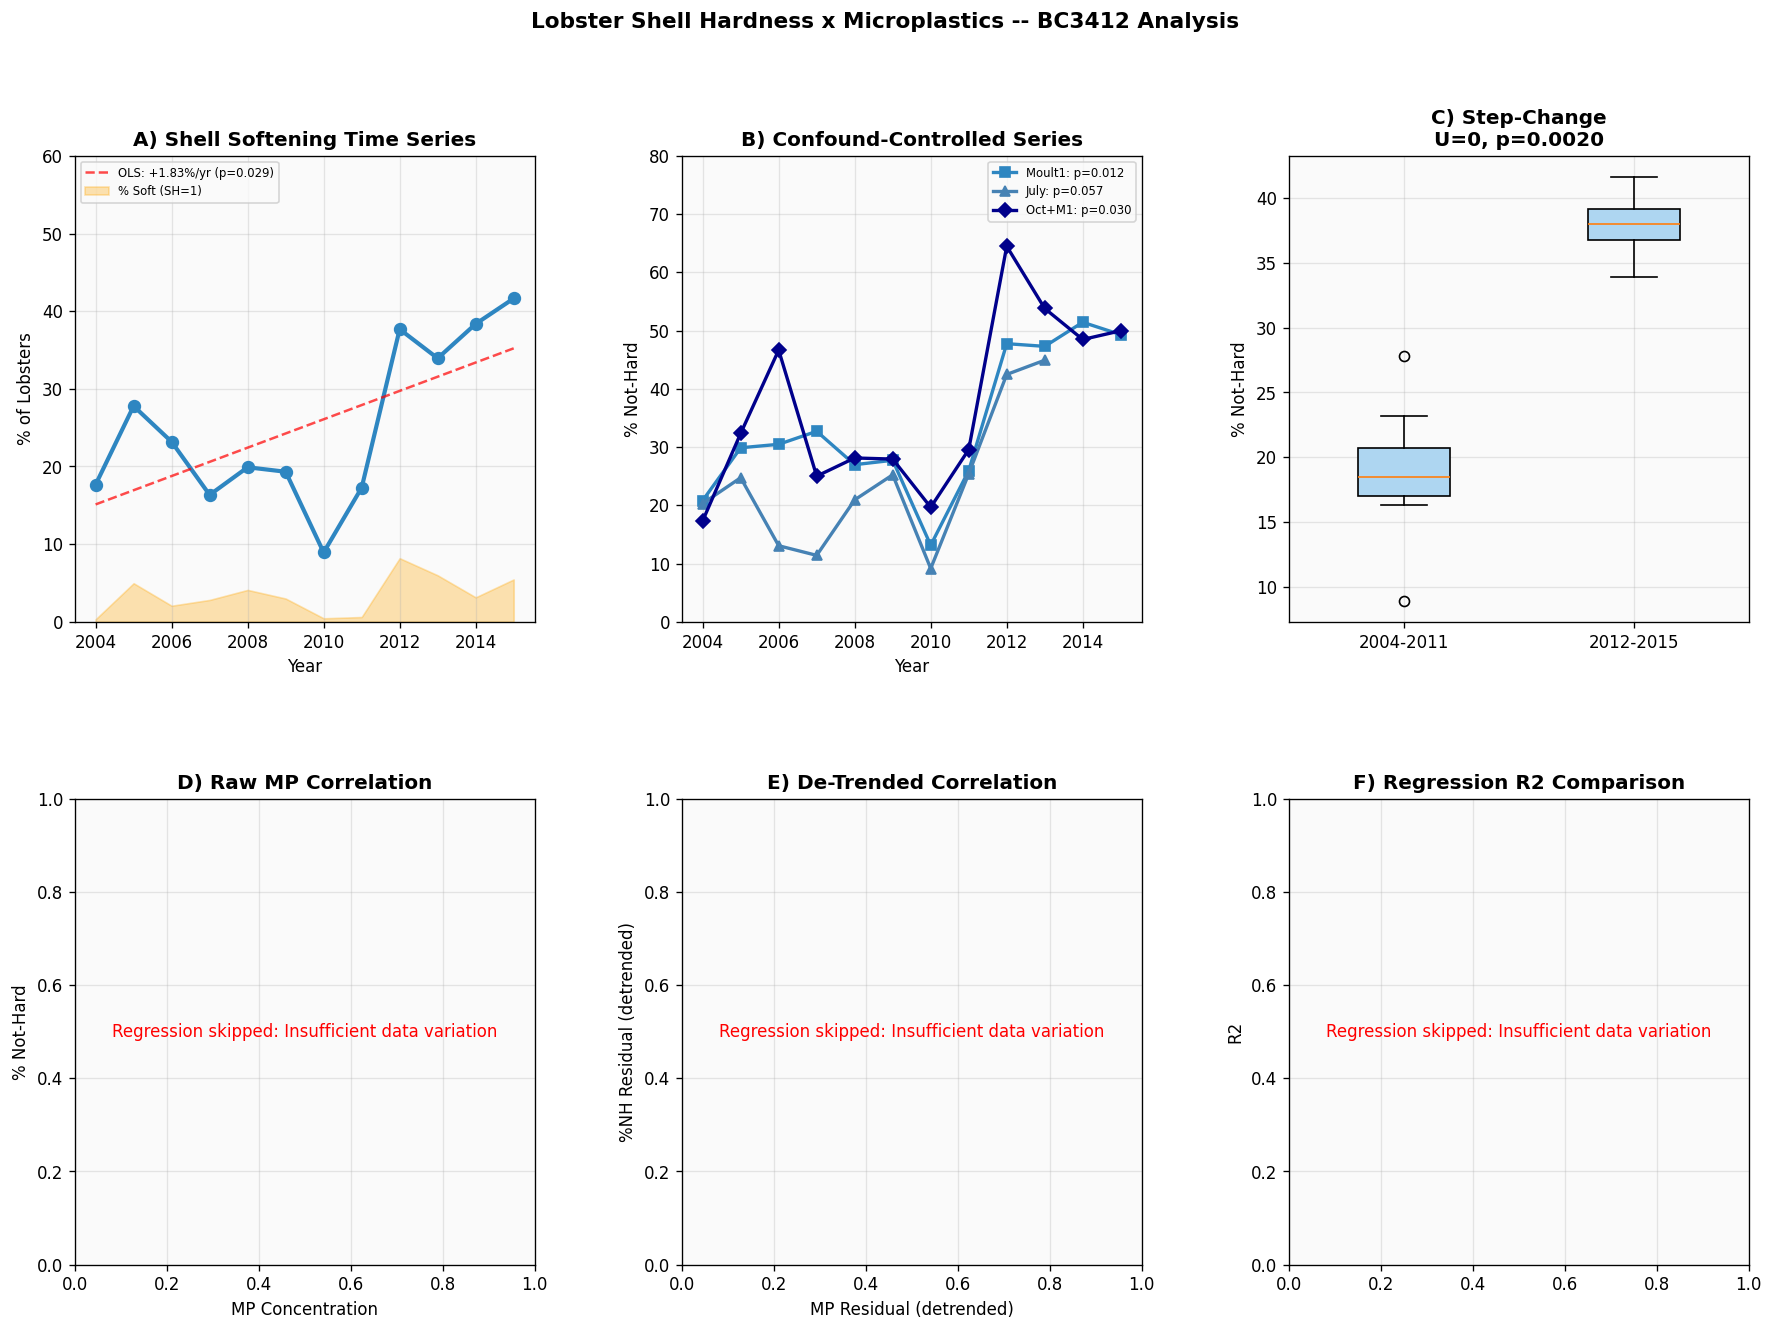

In [64]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.close('all') # Close all existing figures to prevent potential rendering issues

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.32)

# A) Shell softening time series
ax = fig.add_subplot(gs[0, 0])
ax.plot(lob_yr['year'], lob_yr['pct_not_hard'], 'o-', color=C['lob'], lw=2.5, ms=7)
xf = np.linspace(lob_yr['year'].min(), lob_yr['year'].max(), 100)
ax.plot(xf, sl*xf + ic, '--', color='red', alpha=0.7, label=f'OLS: {sl:+.2f}%/yr (p={p_lr:.3f})')
ax.fill_between(lob_yr['year'], 0, lob_yr['pct_soft'], alpha=0.3, color='orange', label='% Soft (SH=1)')
ax.set(xlabel='Year', ylabel='% of Lobsters', ylim=(0, 60))
ax.legend(fontsize=7, loc='upper left')
ax.set_title('A) Shell Softening Time Series', fontweight='bold')

# B) Confound-controlled
ax = fig.add_subplot(gs[0, 1])
if len(msg1_yr) >= 4:
    ax.plot(msg1_yr['year'], msg1_yr['pct_nh'], 's-', color=C['lob'], lw=2, ms=6, label=f'Moult1: p={p1:.3f}')
if len(jul_yr) >= 4:
    ax.plot(jul_yr['year'],  jul_yr['pct_nh'],  '^-', color='steelblue', lw=2, ms=6, label=f'July: p={p2:.3f}')
if len(oct_yr) >= 4:
    ax.plot(oct_yr['year'],  oct_yr['pct_nh'],  'D-', color='darkblue', lw=2, ms=6, label=f'Oct+M1: p={p3:.3f}')
ax.set(xlabel='Year', ylabel='% Not-Hard', ylim=(0, 80))
ax.legend(fontsize=7)
ax.set_title('B) Confound-Controlled Series', fontweight='bold')

# C) Step-change boxplot
ax = fig.add_subplot(gs[0, 2])
ax.boxplot([pre.values, post.values], labels=['2004-2011', '2012-2015'],
           widths=0.4, patch_artist=True, boxprops=dict(facecolor='#AED6F1'))
ax.set_ylabel('% Not-Hard')
ax.set_title(f'C) Step-Change\nU={u_stat:.0f}, p={u_p:.4f}', fontweight='bold')

# Determine if regression plots should be enabled
regression_plot_enabled = True
if regression_df['Aggregated_Microplastics_Concentration'].nunique() <= 1 or regression_df['year'].nunique() <= 1:
    regression_plot_enabled = False

# D) Raw MP correlation
ax = fig.add_subplot(gs[1, 0])
if regression_plot_enabled and len(lob_mp) >= 3:
    ax.scatter(lob_mp['mp_mean'], lob_mp['pct_not_hard'], c=C['lob'], s=70, ec='k', zorder=3)
    for _, row in lob_mp.iterrows():
        ax.annotate(str(int(row['year'])), (row['mp_mean'], row['pct_not_hard']), fontsize=7, ha='center', va='bottom')
    z = np.polyfit(lob_mp['mp_mean'], lob_mp['pct_not_hard'], 1)
    xl = np.linspace(lob_mp['mp_mean'].min(), lob_mp['mp_mean'].max(), 50)
    ax.plot(xl, z[0]*xl + z[1], '--', color='red', alpha=0.5)
    ax.set(xlabel='MP Concentration', ylabel='% Not-Hard')
    t_r = f'rho={r_raw:+.3f}, p={p_raw:.3f}' if not np.isnan(r_raw) else 'N/A'
    ax.set_title(f'D) Raw MP Correlation\n{t_r}', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'Regression skipped: Insufficient data variation', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10, color='red')
    ax.set_title('D) Raw MP Correlation', fontweight='bold')
    ax.set(xlabel='MP Concentration', ylabel='% Not-Hard')

# E) De-trended correlation
ax = fig.add_subplot(gs[1, 1])
if regression_plot_enabled and len(lob_mp) >= 3 and not np.isnan(r_det):
    ax.scatter(lob_mp['mp_mean_resid'], lob_mp['pct_not_hard_resid'], c=C['lob'], s=70, ec='k', zorder=3)
    for _, row in lob_mp.iterrows():
        ax.annotate(str(int(row['year'])), (row['mp_mean_resid'], row['pct_not_hard_resid']), fontsize=7, ha='center', va='bottom')
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set(xlabel='MP Residual (detrended)', ylabel='%NH Residual (detrended)')
    t_d = f'rho={r_det:+.3f}, p={p_det:.3f}' if not np.isnan(r_det) else 'N/A'
    ax.set_title(f'E) De-Trended Correlation\n{t_d}', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'Regression skipped: Insufficient data variation', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10, color='red')
    ax.set_title('E) De-Trended Correlation', fontweight='bold')
    ax.set(xlabel='MP Residual (detrended)', ylabel='%NH Residual (detrended)')

# F) Model R2 comparison
ax = fig.add_subplot(gs[1, 2])
if regression_plot_enabled:
    mods   = ['M1: MP only', 'M2: MP+Year']
    r2s    = [m1.rsquared, m2.rsquared]
    mp_ps  = [mp_p_m1, mp_p_m2]
    colors_bar = [C['oys'] if p < 0.05 else C['gray'] for p in mp_ps]
    ax.bar(range(len(mods)), r2s, color=colors_bar, ec='k', lw=0.5)
    ax.set_xticks(range(len(mods)))
    ax.set_xticklabels(mods, fontsize=8)
    ax.set_ylabel('R2')
    for i in range(len(mods)):
        lbl = '*' if mp_ps[i] < 0.05 else 'ns'
        ax.text(i, r2s[i] + 0.001, f'MP:{lbl}  p={mp_ps[i]:.3f}', ha='center', fontsize=8)
    ax.set_title('F) Regression R2 Comparison', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'Regression skipped: Insufficient data variation', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10, color='red')
    ax.set_title('F) Regression R2 Comparison', fontweight='bold')
    ax.set_ylabel('R2')

plt.suptitle('Lobster Shell Hardness x Microplastics -- BC3412 Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Conclusions

| Dimension | Finding |
|-----------|--------|
| **Shell hardness trend** | OLS slope + Spearman test (Cell 5) |
| **Survives confound control?** | Moult-stage & seasonal sub-series (Cell 7) |
| **Raw MP correlation** | Spearman rho before de-trending (Cell 8) |
| **After de-trending** | Tests independent signal vs. shared trend artefact (Cell 8) |
| **Regression** | Does MP effect survive after controlling for year? (Cell 9) |

### Key Takeaways
1. **De-trending is critical** — Raw MP-health correlation may reflect a shared time trend (ecological correlation fallacy). Inspect `pct_drop` in Cell 8.
2. **Autocorrelation caveat** — If DW < 1.5, OLS p-values are anti-conservative; prefer Spearman for inference.
3. **Confound controls** — If trend disappears under moult/season control, the observed change reflects sampling composition change, not genuine biological deterioration.
4. **Policy implication** — MP regulation alone is insufficient; shellfish health reflects compound stressors (warming, acidification, microplastics).
